# Notebook 3 Implementacion Teoria RL Reto: Interlub
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)


## Instrucciones:
- Active su entorno de `conda`
- Este Notebook es muy similar al de la actividad 5 del modulo 2
- La idea de este Notebook es que usted ponga en el contexto teorico la solucion del reto Interlub
- El codigo de abajo es la solucion del Notebook 5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, chi2, t, kstest, shapiro, f

## 1. Formulación matricial de RLM

Nuestro modelo es

$$y_i=\beta_0+\beta_1x_{i,1}+...+\beta_kx_{i,k}+\epsilon_i$$


Ejercicios:

- Anteriormente, se generaron datos 100% de juguete, el objetivo es adaptar este Notebook para los datos del reto Interlub
- Incluya los datos que genero en las etapas anteriores
- Modifique las lineas de codigo para aumentar el numero de variables explicativas
- Sugerencia: despues de su investigacion de cuales variables son mas importantes en la industria de grasas, enfoquese en alrededor de 5
variables
- Complete las siguientes lineas de codigo siga las instrucciones en los comentarios

In [2]:
# aqui se empieza el 

# incluya sus datos y sustituya/complete las siguientes lineas

n = 1000
k = 2
p = k + 1

# valores verdaderos, como modificaria su logica para adptarlo a interlub?
beta_0 = 2.5
beta_1 = 1.8
beta_2 = -0.5
#beta_3 = 0.3 # beta v3
#beta_4 = 0.7 # beta v4
#beta_5 = -1.2 # beta v5
true_beta = np.array([beta_0, beta_1, beta_2])

X1 = np.linspace(0, 5, n) 
X2 = np.logspace(0, 1, n)
#X3 = np.linspace(0, 5, n) 
#X4 = np.logspace(0, 1, n)
#X5 = np.linspace(0, 5, n) 

# hacer la matriz X, Para el reto extender esta matriz a cuando menos 5 variables explicativas
X_final = np.column_stack([np.ones(n), X1, X2])

Como modificarian sus betas para adptarlo a interlub? Primero investiguen cuales variables son mas importantes en la industria de grasas. Despues de su investigacion de cuales variables son mas importantes en la industria de grasas, enfoquese en alrededor de 5 variables, una vez que tenga esas variables, modifique las betas acorde a su investigacion.

## 2.  Errores

Ejercicios:
- Las lineas de abajo tienen una propuesta poco realista de los errores del model RLM 
- Proponga errores mas realistas para en acorde a grasas encontradas en distintas manufacturas
- Analice el modelo propuesto
- Ejecute las lineas modificadas/aumentadas de codigo

In [3]:
# aqui elija errores 
sigma = 1.5
epsilon = np.random.normal(0, sigma, n)

# RLM matricial
y = X_final @ true_beta + epsilon
print(y)


[ 0.69635194  0.41869611  1.23374264  2.90115582  0.05698511  1.31820251
  1.14753734 -0.26197002  2.2033824   2.94033711  3.76314289  2.27802387
  0.37057275  1.80228433 -1.37589295  2.10789957  2.13843623  0.73006966
  0.20390174  1.98552559  2.53121198  3.98932503  1.70021862  2.96028082
  2.89183753  2.45600869  4.81492897  5.20404021  3.78670191  2.17741298
  0.97933576  5.22238721  1.4336477   2.5531656   2.01755541  1.83052226
  3.79110096  1.44691278  2.75682419  5.35351827  1.63365215  2.18311736
  2.2771326   1.43478024  1.49370525  2.30803994  1.94049396  2.61294752
  3.23066325  3.16049772  3.11120101  4.19550399  3.64290928  1.36610646
 -0.33866534  2.07366375  2.12590053  2.01369222  3.6138054   5.07944892
  1.89598064  2.82308018  1.22677053  5.83758559  2.62322239  3.01631149
 -0.40018777  4.41902523  4.58268988  1.85091021  0.54631424  1.39918911
 -0.57148354  1.32718434  2.81737328  2.52153496  0.29573937 -0.21395347
  0.01748315  1.38334549  0.40541342  1.80897992  3

## 3. Propiedades de la matriz sombrero $\hat{H}$

Ejercicios:
- Analice si la nueva matriz sombrero cumple con las propiedades utiles
- En caso de no cumplir con las propiedades, investigue el motivo y subsane para que lo sea

In [4]:
# construya la matriz X^T X
X_transpose_X = X_final.T @ X_final
print(f"\nX'X matrix ({p} × {p}):")
print(X_transpose_X)

# primero verificar si X^T X es invertible con el rango
rank = np.linalg.matrix_rank(X_transpose_X)
print(f"\nRango of X'X: {rank}/{p}")
print(f"X'X es invertible: {rank == p}")


X'X matrix (3 × 3):
[[ 1000.          2500.          3910.24341546]
 [ 2500.          8337.50417084 13238.98388937]
 [ 3910.24341546 13238.98388937 21526.61730803]]

Rango of X'X: 3/3
X'X es invertible: True


- La matriz sombrero cumple con las propiedades utiles? Si, ya que es simetrica y idempotente

## 4. Estimador de $y (\hat{y})$

Ejercicios:
- Estime y con las lineas de abajo
- Analice y valide en el contexto de grasas si sus resultados van acorde a lo esperado


In [5]:
# ahora encuentre la inversa de X^T X
X_transpose_X_inv = np.linalg.inv(X_transpose_X)

# encuentra beta vector estimador
beta_hat = X_transpose_X_inv @ X_final.T @ y
print(f"True β: {true_beta}")
print(f"OLS β_hat: {beta_hat}")

# encuentre la matriz de covarianza de los estimadores
cov_beta_hat = (sigma ** 2) * X_transpose_X_inv
print(f"\nTheoretical Cov(β_hat):")
print(cov_beta_hat)

# encuentre los errores estandar de las b0, b1,b2... extienda hasta donde usted decido anteriormente
std_errors = np.sqrt(np.diag(cov_beta_hat))
print(f"\nTheoretical Standard Errors:")
print(f"SE(β₀): {std_errors[0]:.4f}")
print(f"SE(β₁): {std_errors[1]:.4f}")
print(f"SE(β₂): {std_errors[2]:.4f}")

# encuentre el estimador de y
y_hat = X_final@X_transpose_X_inv @ X_final.T @ y


True β: [ 2.5  1.8 -0.5]
OLS β_hat: [ 2.38923159  1.84436178 -0.50699332]

Theoretical Cov(β_hat):
[[ 0.00924525 -0.00450201  0.00108939]
 [-0.00450201  0.01370365 -0.00761004]
 [ 0.00108939 -0.00761004  0.00458685]]

Theoretical Standard Errors:
SE(β₀): 0.0962
SE(β₁): 0.1171
SE(β₂): 0.0677


## 5. Interpretacion de los errores

Ejercicios:
- Esta parte es fundamental ya que vamos a poder dar una nocion de que tan buen es el modelo de RLM para atacar problemas del  mundo real
- Lo principal es encontrar una tabla de errores como la estudiada en modulo 2
- Describa de manera cuantitaiva y cualitativa los errores en RLM para el caso de reto Interlub

In [6]:
# encuentre el MSE de y_hat y y medida
mse_rlm = np.sum((y_hat-y)**2)/len(y)
print(mse_rlm, "check mse")

# encuentre los elementos de la tabla de varianzas
# es decir, encuentre SSR, SSE y Syy
# enuncie una explicación integral de cada termino
SSR = np.sum((y_hat - np.mean(y))**2)
SSE = np.sum((y - y_hat)**2)
Syy = np.sum((y - np.mean(y))**2)
print(f"\nSSR: {SSR:.4f}")
print(f"SSE: {SSE:.4f}")
print(f"Syy: {Syy:.4f}")
# verifique que Syy = SSR + SSE
print(f"Syy = SSR + SSE: {np.isclose(Syy, SSR + SSE)}")

2.1513383023048918 check mse

SSR: 2227.0143
SSE: 2151.3383
Syy: 4378.3526
Syy = SSR + SSE: True


Explicación integral de cada termino:
- SSR (Suma de cuadrados de regresión): Este término mide la variabilidad explicada por el modelo de regresión. Representa la cantidad de variación en la variable dependiente (y) que puede ser atribuida a las variables independientes (X). Un valor alto de SSR indica que el modelo explica bien los datos.
- SSE (Suma de cuadrados del error): Este término mide la variabilidad no explicada por el modelo, es decir, la parte de la variación en y que no puede ser explicada por las variables independientes. Un valor bajo de SSE es deseable, ya que indica que el modelo tiene un buen ajuste a los datos.
- Syy (Suma total de cuadrados): Este término mide la variabilidad total en la variable dependiente (y). Es la suma de SSR y SSE, y representa toda la variación en y sin considerar el modelo. Syy es una medida de la dispersión total de los datos alrededor de su media.

## 6. Graficas


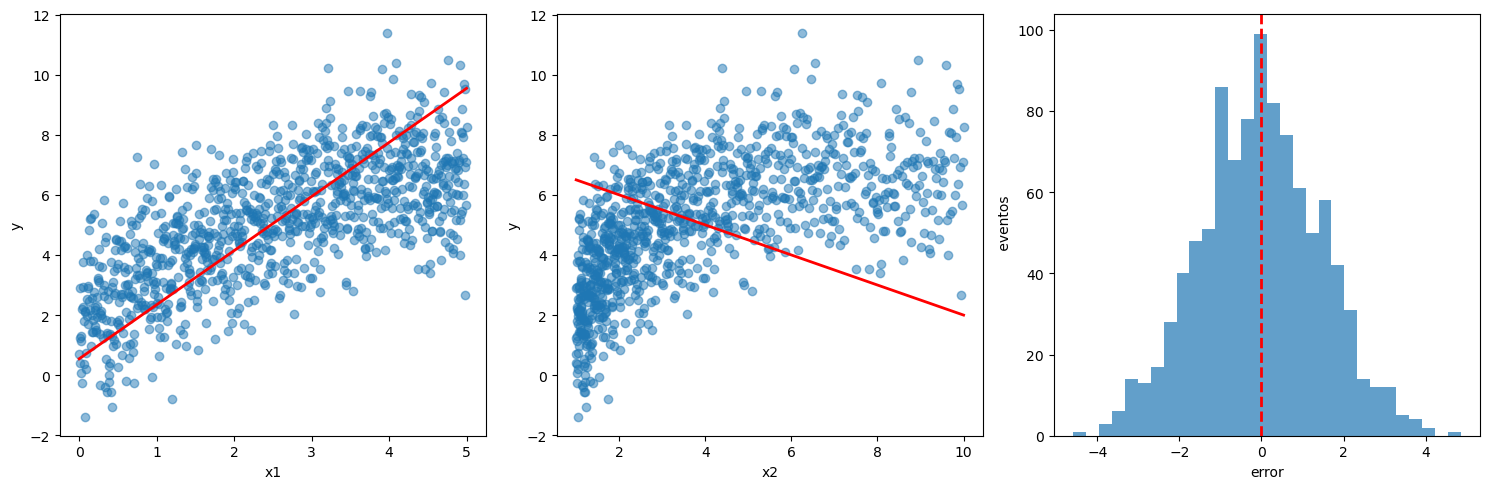

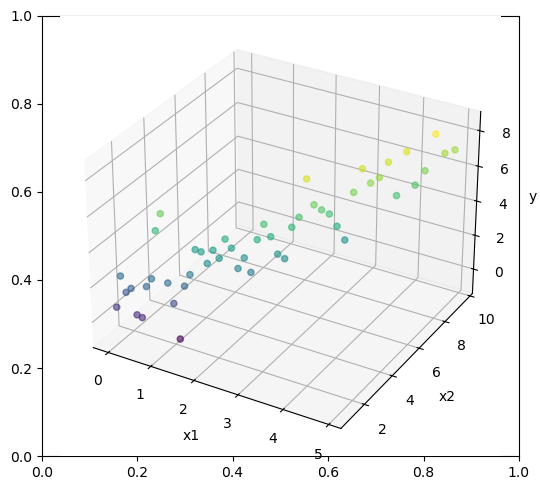

In [7]:
# graficas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# x1
x1_grid = np.linspace(X1.min(), X1.max(), 100)
line_x1 = beta_0 + beta_1 * x1_grid + beta_2 * np.mean(X2)
axes[0].scatter(X1, y, alpha=0.5, label='y experimental')
axes[0].plot(x1_grid, line_x1, 'r-', linewidth=2)
axes[0].set_xlabel('x1')
axes[0].set_ylabel('y')

# x2
x2_grid = np.linspace(X2.min(), X2.max(), 100)
line_x2 = beta_0 + beta_1 * np.mean(X1) + beta_2 * x2_grid
axes[1].scatter(X2, y, alpha=0.5, label='y experimental')
axes[1].plot(x2_grid, line_x2, 'r-', linewidth=2)
axes[1].set_xlabel('x2')
axes[1].set_ylabel('y')

# error
axes[2].hist(epsilon, bins=30, alpha=0.7)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('error')
axes[2].set_ylabel(' eventos')
plt.tight_layout()
plt.show()
fig.clf()

# graficar las dos variables juntas
from mpl_toolkits.mplot3d import Axes3D
fig, axes = plt.subplots(1, 1, figsize=(5.5, 5))
ax_3d = fig.add_subplot(1, 1, 1, projection='3d')
subset = slice(0, n, 20)
scatter = ax_3d.scatter(X1[subset], X2[subset], y[subset], 
                       c=y[subset], cmap='viridis', alpha=0.6)
ax_3d.set_xlabel('x1')
ax_3d.set_ylabel('x2')
ax_3d.set_zlabel('y')
plt.tight_layout()
plt.show()

## 7. F-estadistica de RLM

Ejercicios:
- Complete las siguientes "leads" de código
- Adapte el codigo para dar solucion al reto Interlub

In [8]:
# aqui se empieza el código

# dada la matriz X de la seccion anterior
# muestre que I - X(X'X)-1 X' es idempotente
result = np.eye(n) - X_final @ np.linalg.inv(X_final.T @ X_final) @ X_final.T
print(result)

# encuentre el rango I - X(X'X)-1 X'
# [Sugerencia: rango = np.linalg.matrix_rank()]
rango = np.linalg.matrix_rank(result)
print(rango)

# muestre que X(X'X)-1 X' es idempotente
result = X_final @ np.linalg.inv(X_final.T @ X_final) @ X_final.T
print(result)

# encuentre el rango de X(X'X)-1 X'
# [Sugerencia: rango = np.linalg.matrix_rank()]
print(rango)


# muestre que (I - X(X'X)-1 X')*(X(X'X)-1 X) = 0
# cuales son las consecuencias de esto
identity_result = result @ (np.eye(n) - result)
print(identity_result)


# ahora usando la y vector de la seccion anterior
# y las betas y sus estimadores
# encuentre la estadística lambda (resultado del Lemma de Neyman-Pearson)
lambda_stat = (y.T @ (np.eye(n) - X_final @ np.linalg.inv(X_final.T @ X_final) @ X_final.T) @ y) / \
               (y.T @ (X_final @ np.linalg.inv(X_final.T @ X_final) @ X_final.T) @ y)
print(f"\nLambda statistic: {lambda_stat:.4f}")



[[ 0.99288405 -0.00709483 -0.00707372 ... -0.00284311 -0.00287411
  -0.00290525]
 [-0.00709483  0.99292621 -0.00705277 ... -0.0028257  -0.00285654
  -0.0028875 ]
 [-0.00707372 -0.00705277  0.99296817 ... -0.00280831 -0.00283898
  -0.00286978]
 ...
 [-0.00284311 -0.0028257  -0.00280831 ...  0.98857244 -0.01149071
  -0.01155407]
 [-0.00287411 -0.00285654 -0.00283898 ... -0.01149071  0.98844568
  -0.01161813]
 [-0.00290525 -0.0028875  -0.00286978 ... -0.01155407 -0.01161813
   0.98831761]]
997
[[0.00711595 0.00709483 0.00707372 ... 0.00284311 0.00287411 0.00290525]
 [0.00709483 0.00707379 0.00705277 ... 0.0028257  0.00285654 0.0028875 ]
 [0.00707372 0.00705277 0.00703183 ... 0.00280831 0.00283898 0.00286978]
 ...
 [0.00284311 0.0028257  0.00280831 ... 0.01142756 0.01149071 0.01155407]
 [0.00287411 0.00285654 0.00283898 ... 0.01149071 0.01155432 0.01161813]
 [0.00290525 0.0028875  0.00286978 ... 0.01155407 0.01161813 0.01168239]]
997
[[8.53809211e-17 8.37004077e-17 8.67903839e-17 ... 8.521

Consecuencias: La multiplicación de estas dos matrices da como resultado la matriz cero, lo que indica que los espacios proyectados por estas dos matrices son ortogonales entre sí. Esto significa que la proyección de cualquier vector en el espacio definido por X(X'X)-1 X' no tiene componente en el espacio definido por I - X(X'X)-1 X', y viceversa. En términos prácticos, esto refleja la propiedad de que la variabilidad explicada por el modelo (proyectada por X(X'X)-1 X') es independiente de la variabilidad no explicada (proyectada por I - X(X'X)-1 X').




## 8. Investigacion mas alla del Notebook

Ejercicios:
- Aumente la forma en que puede caracterizar los resultados de RLM
- Que otras metricas podrian ser utiles? Algunas otras metricas utiles pueden ser:
  - R-cuadrado ajustado
  - Error cuadrático medio (MSE)
  - Error absoluto medio (MAE)
  - Criterio de información de Akaike (AIC)
  - Criterio de información bayesiano (BIC)
  - Análisis de residuos
  - Validación cruzada

- Busque otros modelos que puedan superar al RLM. Otros modelos que podrían superar al RLM incluyen:
  - Regresión polinómica
  - Regresión de Ridge y Lasso
  - Máquinas de vectores de soporte (SVM)
  - Árboles de decisión y bosques aleatorios
  - Redes neuronales
  - Modelos de ensamble como Gradient Boosting Machines (GBM) y XGBoost
  
- Use su imaginacion para hacer la solucion de reto mejor